# HYDROAWARE project

## Preprocessing Global and Continental scale datasets

These Jupyter Notebook include a list of datasets that are publicly available. To use them in the DRYP model we have preprocess all of them in order to harmonize them into common model grid domain.

To achive this we have perform some of the following operations depending on the datasets:

- Clip to the extend of the Africa continent
- Regrid to a 30 arcsec
- Calculate gradients
- Calculate percentiles
- Spatial aggregation

In [141]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import rasterio
import xarray as xr
import rioxarray
from rasterio.warp import calculate_default_transform, reproject, Resampling
#from rasterio.enums import Resampling
from rasterio.crs import CRS
from rasterio.errors import CRSError
import warnings
import os
import shapefile as shp

In [142]:
from rasterio.plot import show
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import cm
import matplotlib.pyplot as plt


In [143]:
import os
import sys
sys.path.append("/home/c1755103/CUWALID/")
from notebooks.general_function_all import *
import notebooks.plotting_functions_fluxes as pltcwld

In [144]:
fname_basin = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev03_v1c.shp"
fname_country = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev03_v1c.shp"
basin = shp.Reader(fname_basin)
country = shp.Reader(fname_country)


In [145]:
# get the bounding box of the basin shapefile
bounds = basin.bbox

In [146]:
fname_baslevel3 = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev03_v1c.shp"

In [147]:
# HYDROSHEDS - Global 30 arc-second (approximately 1 km) resolution data
fname_dem = "/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif"
fname_acc = "/home/c1755103/AF/dataset/raw/hyd_af_acc_30s.tif"
fname_dir = "/home/c1755103/AF/dataset/raw/hyd_af_dir_30s.tif"    

In [148]:
# Post-processed datasets
fname_cigar = "/home/c1755103/AF/dataset/postpp/af_ai_v3_yr_cigar.tif"
fname_csiro = "/home/c1755103/AF/dataset/postpp/af_Effective_Rooting_Depth.tif"
fname_soil_sed_thkns = "/home/c1755103/AF/dataset/postpp/af_average_soil_and_sedimentary-deposit_thickness.tif"
fname_gires = "/home/c1755103/AF/dataset/postpp/af_gires.tif"
fname_head_boundary = "/home/c1755103/AF/dataset/postpp/af_head_boundary_basin_lvl0.tif"
fname_lambda = "/home/c1755103/AF/dataset/postpp/af_lambda_l1.tif"
fname_psi_s = "/home/c1755103/AF/dataset/postpp/af_psi_s_l1.tif"
fname_log_k_s = "/home/c1755103/AF/dataset/postpp/af_log_k_s_l1.tif"
fname_theta_s = "/home/c1755103/AF/dataset/postpp/af_theta_s_l1.tif"
fname_k_s = "/home/c1755103/AF/dataset/postpp/af_k_s_l1.tif"


In [149]:
bounds = get_bounds(fname_acc)

In [66]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_cigar)[0].values
# --- 2 preprocess data
data = data*0.0001
data[data<=0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_ai_v3_yr_cigar_map.png"

<Axes: >

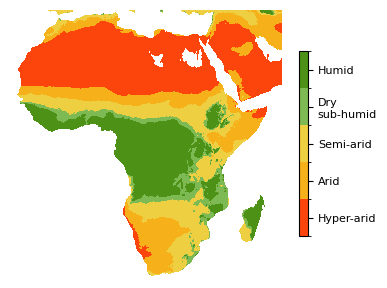

In [49]:
pltcwld.plot_ai_map_contour_new(
        data, bounds, ctr_data=None,
        country=None, basin=None,
        cmap="cividis",
        alpha=1.0,
        shrink=0.5,
        formatcbar="%.1f",
        plot_contour=False,
        label_ctr=False,
        fontsize_ctr=8,
        fmt_ctr="%d",
        vmax=1.0, vmin=0,
        lu=7,
        vmax_ctr=1.0, vmin_ctr=0,
        color_ctr="gray", lws_ctr=0.25,
        axisoff=True,
        title="",
        width=4, height=4,
        foutput=path_out
)

In [13]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_dem)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
#data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_dem_30s_map.png"

/home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/rioxarray/_io.py:1143: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  warnings.warn(str(rio_warning.message), type(rio_warning.message))  # type: ignore


<Axes: title={'center': 'Elevation [m]'}>

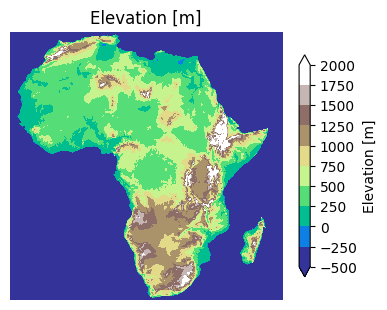

In [15]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="terrain",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Elevation [m]", shade=False,
		alpha=1.0, vmax=2000.0, vmin=-500.0, scale=1.0, lu=10,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

### Calculate channel slope

This uses the DEM to calculate slope

In [ ]:
# calculate slope from dem
from scipy import ndimage
def calculate_slope(dem, transform):
    # Calculate the gradient in x and y directions
    x_gradient = ndimage.sobel(dem, axis=1) / (8 * transform.a)  # transform.a is pixel width
    y_gradient = ndimage.sobel(dem, axis=0) / (8 * transform.e)  # transform.e is pixel height

    # Calculate the slope in radians
    #slope_rad = np.arctan(np.sqrt(x_gradient**2 + y_gradient**2))

    # Convert slope to degrees
    #slope_deg = np.degrees(slope_rad)

    # caculate slope
    slope = np.sqrt(x_gradient**2 + y_gradient**2)

    return slope

In [ ]:
path_dem = "/home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif"
# calulate slope from dem
data_dem = rioxarray.open_rasterio(path_dem)
slope = calculate_slope(data_dem[0].values, data_dem.rio.transform())
slope = np.flip(slope,0)

# plot slope map
#path_out = "/home/c1755103/AF/fig/af_slope_30s_q1_map.png"
#pltcwld.plot_map_countour(slope, bounds, ctr_data=None,
#        country=None, basin=None, mask=None, xscale=None,
#        yscale=None, title="Slope Map", cmap="viridis", path_out=path_out)

# save slope as geotiff
slope_da = xr.DataArray(slope, coords=data_dem[0].coords, dims=data_dem[0].dims)
slope_da.rio.to_raster("/home/c1755103/AF/dataset/postpp/af_slope_30s_q1.tif")

### Flow accumulation

In [95]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_acc)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_acc_30s_map.png"

<Axes: title={'center': 'Flow accumulation'}>

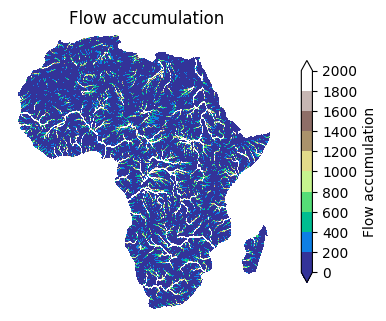

In [97]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="terrain",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Flow accumulation", shade=False,
		alpha=1.0, vmax=2000.0, vmin=0.0, scale=1.0, lu=10,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

###  River network

In [87]:
# read flow accumulation raster and create a binary river mask
data = rioxarray.open_rasterio(fname_acc)

# make masked river cells equal to 1 and all other cells 0
river_mask = (data[0].values >= 10).astype(np.uint8)
river_mask = np.flip(river_mask,0)
# save river mask as GeoTIFF
river_da = xr.DataArray(river_mask, coords=data[0].coords, dims=data[0].dims)
river_da = river_da.rio.write_crs(data.rio.crs)
river_da = river_da.rio.write_transform(data.rio.transform())
river_da.rio.to_raster("/home/c1755103/AF/dataset/postpp/af_river_mask_30s.tif")

<Axes: title={'center': 'River Map'}>

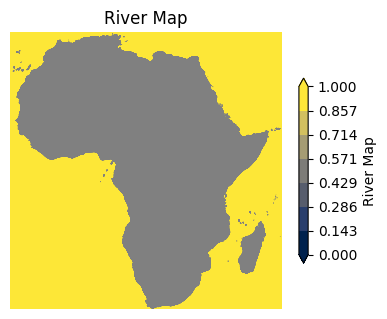

In [91]:
path_out = "/home/c1755103/AF/fig/af_river_mask_30s_map.png"
pltcwld.plot_map_countour(river_mask, bounds, ctr_data=None,
        country=None, basin=None, mask=None,# xscale=None,
        vmax=1.0, vmin=0.0,
        #yscale=None,
        title="River Map",# cmap="viridis"#, path_out=path_out
        )

### Flow direction

In [12]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_dir)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_dir_30s_map.png"

<Axes: title={'center': 'Elevation [m]'}>

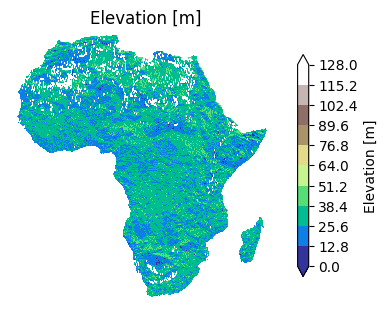

In [25]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="terrain",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Elevation [m]", shade=False,
		alpha=1.0, vmax=128, vmin=0, scale=1.0, lu=10,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [14]:
# save raster dtaset as geoTIFF
data = rioxarray.open_rasterio(fname_dir)[0]
data.rio.to_raster("/home/c1755103/AF/dataset/postpp/af_dir_30s.tif")

In [99]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_csiro)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<=0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_Effective_Rooting_Depth_map.png"

<Axes: title={'center': 'Rooting Depth [m]'}>

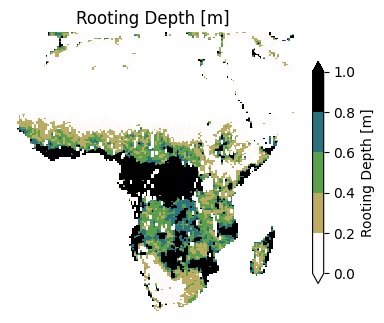

In [101]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Rooting Depth [m]", shade=False,
		alpha=1.0, vmax=1.0, vmin=0.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [57]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_soil_sed_thkns)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<=0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_average_soil_and_sedimentary-deposit_thickness_map.png"

<Axes: title={'center': 'Sediment thickness [m]'}>

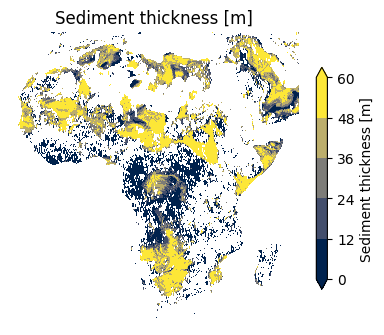

In [59]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Sediment thickness [m]", shade=False,
		alpha=1.0, vmax=60.0, vmin=0.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [55]:
fname_sed_thkns = "/home/c1755103/AF/dataset/postpp/af_upland_valley-bottom_and_lowland_sedimentary_deposit_thickness.tif"

<Axes: title={'center': 'Sediment thickness [m]'}>

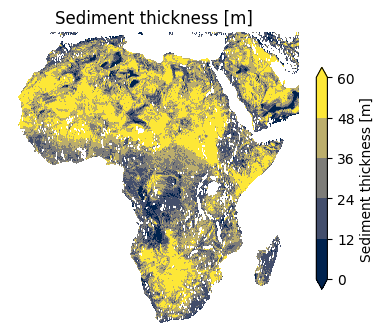

In [56]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_sed_thkns)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<=0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_average_sedimentary_deposit_thickness_map.png"
#data
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Sediment thickness [m]", shade=False,
		alpha=1.0, vmax=60.0, vmin=0.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [35]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_gires)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_gires.png"

<Axes: title={'center': 'Perennial and Intermitent streams'}>

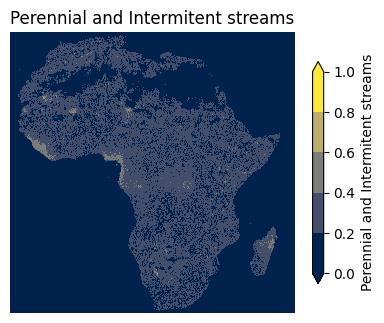

In [36]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Perennial and Intermitent streams", shade=False,
		alpha=1.0, vmax=1.0, vmin=0.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

### Head boundary conditions

In [50]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_head_boundary)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_hydrosheds_lvl1_head_boundary.png"

<Axes: title={'center': 'Perennial and Intermitent streams'}>

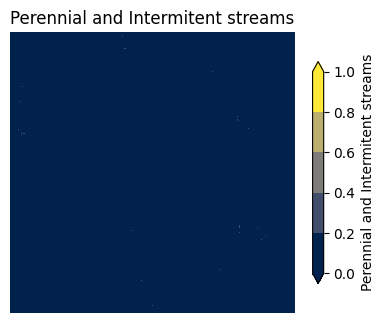

In [52]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Perennial and Intermitent streams", shade=False,
		alpha=1.0, vmax=1.0, vmin=0.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

### Plot soil properties

In [108]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_k_s)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_hydrosheds_lvl1_k_s.png"

In [109]:
#data
#plt.imshow(data)
np.nanmin(data), np.nanmax(data)

(2.08756685256958, 290.33099365234375)

<Axes: title={'center': 'Saturated Ksat'}>

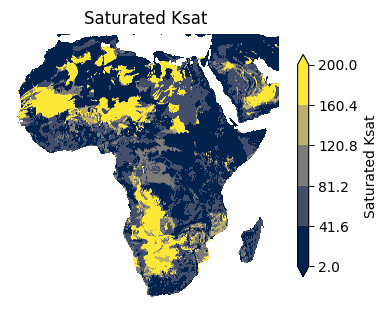

In [111]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Saturated Ksat", shade=False,
		alpha=1.0, vmax=200.0, vmin=2.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [114]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_lambda)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_hydrosheds_lvl1_lambda.png"

In [115]:
#data
#plt.imshow(data)
np.nanmin(data), np.nanmax(data)

(0.05398325457595418, 0.405700177881544)

<Axes: title={'center': 'Soil particle size distribution'}>

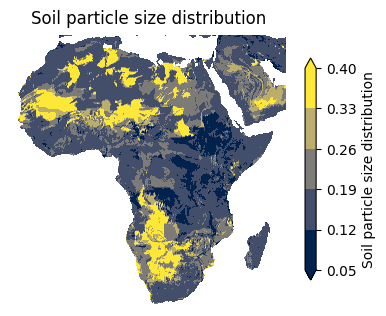

In [116]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Soil particle size distribution", shade=False,
		alpha=1.0, vmax=0.40, vmin=0.05, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [128]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_psi_s)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
#data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_hydrosheds_lvl1_psi_s.png"

In [129]:
#data
#plt.imshow(data)
np.nanmin(data), np.nanmax(data)

(-1e+36, -5.368870417977471)

<Axes: title={'center': 'Air entry pressure'}>

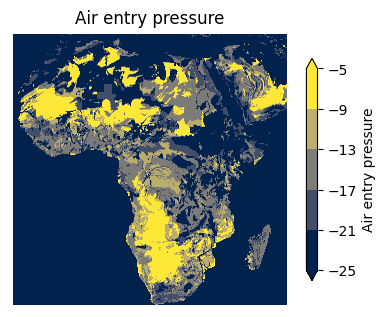

In [130]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Air entry pressure", shade=False,
		alpha=1.0, vmax=-5.0, vmin=-25.0, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

In [125]:
# --- 1. Open GeoTIFF as xarray DataArray ---
data = rioxarray.open_rasterio(fname_theta_s)[0].values
# --- 2 preprocess data
#data = data*0.0001
data = np.array(data, dtype=float)
#data = data[0].values
data[data<0] = np.nan
data = np.flip(data,0)
path_out = "/home/c1755103/AF/fig/af_hydrosheds_lvl1_theta_s.png"

In [126]:
#data
#plt.imshow(data)
np.nanmin(data), np.nanmax(data)

(0.03603308268186145, 0.8658753566791859)

<Axes: title={'center': 'Soil saturated water content'}>

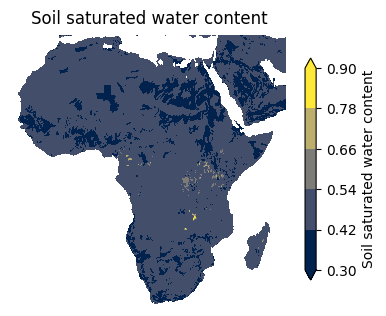

In [127]:
pltcwld.plot_map_countour(data, bounds, ctr_data=None,
		country=None, basin=None, mask=None, xscale=None,
		lw=None, cmap="cividis",#gist_earth_r",
		background=False,
		units=1.0,
		xlim=None, ylim=None, markersize=None, colours_default=True,
		width=4, hight=4.0, ax=None, title="Soil saturated water content", shade=False,
		alpha=1.0, vmax=0.9, vmin=0.3, scale=1.0, lu=5,
		shrink=0.6, formatcbar="%.1f", cbarorientation=None,
		plot_contour=False, label_ctr=False, fontsize_ctr=8, fmt_ctr="%d",
		lu_ctr=7, vmax_ctr=1.0, vmin_ctr=0, color_ctr="gray", lws_ctr=0.25,
		plot_cbar=True,
        axisoff=True,
		foutput=path_out)

### Calculate mean values from global dataset

The script below read a global dataset and extract the area corresponding to the Africa continent.
Data source:
https://springernature.figshare.com/articles/dataset/FLO1K_-_Mean_Annual_Flow_Time_Series_1960-2015/5688916?backTo=%2Fcollections%2FFLO1K_global_maps_of_mean_maximum_and_minimum_annual_streamflow_at_1_km_resolution_from_1960_through_2015%2F3890224&file=10598158


In [48]:
fname_flow1k = "/share/home/c1755103/dataset/FLOW1K/FLO1K.ts.1960.2015.qav.nc"

# open the netCDF file using xarray
ds = xr.open_dataset(fname_flow1k)

# write crs information to the dataset
ds.rio.write_crs("EPSG:4326", inplace=True)

# clip the dataset to the bounds of Africa
ds = ds.rio.clip_box(minx=bounds[0], miny=bounds[2], maxx=bounds[1], maxy=bounds[3])

# calculate the mean over the time dimension
ds = ds['qav'].mean(dim='time')

# save the mean as a new netCDF file
ds.to_netcdf("/share/home/c1755103/dataset/FLOW1K/FLO1K.ts.1960.2015.qav_mean.nc")

In [46]:
bounds#[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3]

[-19.0, 54.9999999999997, -35.0, 37.999999999999716]

In [164]:
src_path = "/share/home/c1755103/dataset/soilgrids/gyga_af_agg_erzd_pwp__m_1km.tif"
out_path = "/home/c1755103/AF/dataset/postpp/gyga_af_agg_erzd_pwp__m_1km_reprojected.tif"

## Clip/crop raster datasets

The following operation cut global dataset, with similar resolution of the reference dataset, to the extend of the reference dataset.

Below we use the harmonized datasets from HYDROSHEDS are reference grid data. 

In [ ]:
fname_cigar = "/share/home/c1755103/dataset/Global-AI_ET0_v3_annual/ai_v3_yr.tif"
fname_csiro = "/share/home/c1755103/dataset/Global_effective_plant_rooting_depth/Effective_Rooting_Depth.tif"
fname_soil_sed_thkns = "/share/home/c1755103/dataset/Global_Soil_Regolith_Sediment_1304/data/average_soil_and_sedimentary-deposit_thickness.tif"

Aridity index


In [82]:
src_path = "/share/home/c1755103/dataset/Global-AI_ET0_v3_annual/ai_v3_yr.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_ai_v3_yr_cigar.tif"

Plant effective rooting depth

In [160]:
src_path = "/share/home/c1755103/dataset/Global_effective_plant_rooting_depth/Effective_Rooting_Depth.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_Effective_Rooting_Depth.tif"

Pelletier, global sediments and regolite thickness


In [77]:
src_path = "/share/home/c1755103/dataset/Global_Soil_Regolith_Sediment_1304/data/average_soil_and_sedimentary-deposit_thickness.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_average_soil_and_sedimentary-deposit_thickness.tif"

In [48]:
src_path = "/share/home/c1755103/dataset/Global_Soil_Regolith_Sediment_1304/data/upland_valley-bottom_and_lowland_sedimentary_deposit_thickness.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_upland_valley-bottom_and_lowland_sedimentary_deposit_thickness.tif"

Global intermitent streams
https://daac.ornl.gov/SOILS/guides/Global_Soil_Regolith_Sediment.html

In [27]:
src_path = "/share/home/c1755103/dataset/GIRES_v10.gdb"
out_path = "/home/c1755103/AF/dataset/postpp/af_gires.tif"

Global water table depth from GLOBWB:

https://gee-community-catalog.org/projects/globgm/#data-citation

In [134]:
src_path = "/home/c1755103/AF/dataset/raw/Africa_WaterTableDepth_30arcsec.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_water_table_depth_30s.tif"

Reference dataset from HYDROSHEDS

In [165]:
ref_path = "/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif"

In [166]:
# --------- BEFORE YOU RUN
# this cell make sure you have set up the correct paths for src_path, out_path, and ref_path.
# The src_path should point to the original raster you want to reproject/clip,
# the out_path is where you want to save the processed raster, and
# the ref_path should point to the reference raster that defines the target grid and CRS.

# ------------------ Robust Raster Reprojection/Clipping to Reference Grid -------------
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterio.crs import CRS
from rasterio.errors import CRSError
import warnings
import os

# Helper to attempt to load a "better" reference if .ovr was given
def try_get_base_raster(path):
    if path.lower().endswith('.ovr'):
        candidate = path[:-4]  # remove .ovr
        if os.path.exists(candidate):
            return candidate
    return path

ref_path_try = try_get_base_raster(ref_path)

with rasterio.open(ref_path_try) as ref:
    ref_crs = ref.crs
    ref_bounds = ref.bounds
    ref_width = ref.width
    ref_height = ref.height

with rasterio.open(src_path) as src:
    src_crs = src.crs
    print(f"Source CRS: {src_crs}, Reference CRS: {ref_crs}")
    # --- Robust CRS handling ---
    # If either CRS is None or invalid, try to fix or fall back to EPSG:4326
    if ref_crs is None:
        warnings.warn(
            f"Reference CRS is missing (ref_path='{ref_path_try}'). "
            "If this is an .ovr, try using the base .tif. Falling back to src CRS or EPSG:4326."
        )
        ref_crs = src_crs if src_crs is not None else CRS.from_epsg(4326)

    if src_crs is None:
        warnings.warn("Source CRS is missing. Setting source CRS to EPSG:4326 as fallback.")
        src_crs = CRS.from_epsg(4326)

    # Ensure we have proper rasterio CRS objects
    try:
        # this will raise CRSError if either is invalid
        src_crs = CRS(src_crs) if not isinstance(src_crs, CRS) else src_crs
        ref_crs = CRS(ref_crs) if not isinstance(ref_crs, CRS) else ref_crs
    except CRSError:
        # try parsing WKT strings explicitly, or fallback
        try:
            if isinstance(ref_crs, str):
                ref_crs = CRS.from_wkt(ref_crs)
            else:
                ref_crs = CRS.from_epsg(4326)
        except Exception:
            ref_crs = CRS.from_epsg(4326)
        try:
            if isinstance(src_crs, str):
                src_crs = CRS.from_wkt(src_crs)
            else:
                src_crs = CRS.from_epsg(4326)
        except Exception:
            src_crs = CRS.from_epsg(4326)

    # --- Calculate transform/shape to match reference raster ---
    try:
        transform, width, height = calculate_default_transform(
            src_crs, ref_crs, ref_width, ref_height, *ref_bounds
        )
    except Exception as e:
        raise RuntimeError(
            "Failed to calculate transform. Check that src and ref CRS are valid. "
            f"src_crs={src_crs}, ref_crs={ref_crs}. Original error: {e}"
        )

    # --- Prepare kwargs for output (reprojected/aligned to ref grid) ---
    kwargs = src.meta.copy()
    kwargs.update({
        'crs': ref_crs,
        'transform': transform,
        'width': width,
        'height': height
    })

    # --- Reproject and save ---
    with rasterio.open(out_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src_crs,
                dst_transform=transform,
                dst_crs=ref_crs,
                resampling=Resampling.nearest
            )

print("✅ Raster successfully reprojected/clipped to reference grid (saved to):", out_path)


Source CRS: PROJCS["unnamed",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Lambert_Azimuthal_Equal_Area"],PARAMETER["latitude_of_center",5],PARAMETER["longitude_of_center",20],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]], Reference CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]
✅ Raster successfully reprojected/clipped to reference grid (saved to): /home/c1755103/AF/dataset/postpp/gyga_af_agg_erzd_pwp__m_1km_reprojected.tif


In [ ]:
# reproject and save using rioxarray (alternative method)
import rioxarray

## Clip/Cut/Extract data from nc datasets

In [108]:
path_source = "/share/home/c1755103/dataset/Dai_et_al_soil_global/psi_s_l1.nc"
ref_path = "/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_psi_s_l1.tif"


In [ ]:
def clip_raster_to_africa(path_source, ref_path, out_path, bounds):
    # read dataset as xarray DataArray and save as GeoTIFF, clipping to Africa bounds
    ds = xr.open_dataset(path_source)
    da = ds['psi_s']

    # rename spatial dimensions for rioxarray if needed
    rename_map = {}
    if 'lon' in da.dims:
        rename_map['lon'] = 'x'
    elif 'longitude' in da.dims:
        rename_map['longitude'] = 'x'

    if 'lat' in da.dims:
        rename_map['lat'] = 'y'
    elif 'latitude' in da.dims:
        rename_map['latitude'] = 'y'

    if rename_map:
        da = da.rename(rename_map)

    # write spatial metadata
    da = da.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=False)
    da = da.rio.write_crs('EPSG:4326', inplace=False)

    # open reference raster and clip to Africa bounds
    ref_da = rioxarray.open_rasterio(ref_path)
    da_clipped = da.rio.clip_box(
        minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3]
     )

    # reproject to match the reference raster grid exactly
    da_matched = da_clipped.rio.reproject_match(ref_da)

    # save the reprojected dataset as GeoTIFF
    da_matched.rio.to_raster(out_path)
    print(f'Saved clipped raster to: {out_path}')

Saved clipped raster to: /home/c1755103/AF/dataset/postpp/af_psi_s_l1.tif


In [107]:
# chek if the saved raster has the same shape and bounds as the reference raster
with rasterio.open(out_path) as dst:
    out_bounds = dst.bounds
    out_width = dst.width
    out_height = dst.height

# check if the saved raster has the same shape and bounds as the reference raster
with rasterio.open(ref_path) as ref:
    ref_bounds = ref.bounds
    ref_width = ref.width
    ref_height = ref.height

if (out_bounds == ref_bounds) and (out_width == ref_width) and (out_height == ref_height):
    print("The saved raster matches the reference raster.")
else:
    print("The saved raster does not match the reference raster.")

The saved raster matches the reference raster.


## Rasterize shapefile

This section create a raster file from a shapefile using a reference raster file. The output is a raster file with the same size of the reference file.

In [20]:
#path_in = "/share/home/c1755103/dataset/GIRES_v10_shp/GIRES_v10_rivers_af.shp"
# Paths
#fname_dem = "/home/c1755103/AF/dataset/raw/af_dem_30s/af_dem_30s.ovr"
shp_path = "/share/home/c1755103/dataset/GIRES_v10_shp/GIRES_v10_rivers_af.shp"
ref_raster_path = "/home/c1755103/AF/dataset/raw/af_dem_30s/af_dem_30s.ovr"
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_gires.tif"

In [151]:
import geopandas as gpd
import rasterio
from rasterio import features
import numpy as np

# Helper to attempt to load a "better" reference if .ovr was given
def try_get_base_raster(path):
    if path.lower().endswith('.ovr'):
        candidate = path[:-4]  # remove .ovr
        if os.path.exists(candidate):
            return candidate
    return path

#ref_path_try = try_get_base_raster(ref_raster_path)

def raster_from_shapefile(shp_path, ref_raster_path, out_raster_path, attribute_field=None):
    ref_path_try = try_get_base_raster(ref_raster_path)
    # 1. Read reference raster
    with rasterio.open(ref_path_try) as ref:
        ref_meta = ref.meta.copy()
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_shape = (ref.height, ref.width)
        if ref_crs is None:
            warnings.warn("Source CRS is missing. Setting source CRS to EPSG:4326 as fallback.")
            ref_crs = CRS.from_epsg(4326)
    print("Reference raster shape:", ref_shape)
    print("Reference transform:", ref_transform)
    print("Reference CRS:", ref_crs)

    # 2. Read shapefile
    gdf = gpd.read_file(shp_path)

    # 3. Reproject shapefile if needed
    if gdf.crs != ref_crs:
        print("Reprojecting shapefile from", gdf.crs, "to", ref_crs)
        gdf = gdf.to_crs(ref_crs)

    # 4. Prepare shapes + values for rasterization
    #    Suppose you want to burn a constant value (e.g. 1) for all geometries,
    #    or you want to use an attribute field.

    if attribute_field is not None and attribute_field in gdf.columns:
        geoms = [(geom, value) for geom, value in zip(gdf.geometry, gdf[attribute_field])]
    else:
        # Option A: All shapes = 1
        geoms = [(geom, 1) for geom in gdf.geometry]

    # Option B: Use attribute field, e.g. "class_id"
    #geoms = [(geom, value) for geom, value in zip(gdf.geometry, gdf["predcat1"])]

    # Rasterize
    rasterized = features.rasterize(
        geoms,
        out_shape=ref_shape,
        transform=ref_transform,
        fill=0,                # value for background
        all_touched=True,     # or True, depending on how you want to treat boundary pixels
        dtype=int#np.uint8         # or another dtype appropriate for your values
    )

    # 5. Write out as new raster
    out_meta = ref_meta
    # Update metadata: probably only need to change count, dtype, maybe nodata
    out_meta.update({
        "driver": "GTiff",
        "height": ref_shape[0],
        "width": ref_shape[1],
        "transform": ref_transform,
        "dtype": rasterized.dtype,
        "nodata": -9999,  # number of bands
        "count": 1,  # number of bands
    })

    with rasterio.open(out_raster_path, "w", **out_meta) as dst:
        dst.write(rasterized, indexes=1)

    print("Rasterization complete. Saved to:", out_raster_path)


In [58]:
shp_path = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev01_v1c.shp"
ref_raster_path = "/home/c1755103/AF/dataset/raw/af_dem_30s/af_dem_30s.ovr"
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_mask_lvl1.tif"

In [59]:
raster_from_shapefile(shp_path, ref_raster_path, out_raster_path)

Reference raster shape: (8760, 8880)
Reference transform: | 0.01, 0.00,-19.00|
| 0.00,-0.01, 38.00|
| 0.00, 0.00, 1.00|
Reference CRS: EPSG:4326
Rasterization complete. Saved to: /home/c1755103/AF/dataset/postpp/af_mask_lvl1.tif


The script below rasterizes polylines from shapefiles. It reads a polygon file and convert it to polylines before it is rasterized. 

In [ ]:
# Paths
poly_shp_path = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev01_v1c.shp"
polyline_shp = "/home/c1755103/AF/dataset/raw/basins/hybas_af_lev01_v1c_polyline.shp"
#ref_raster_path = "/home/c1755103/AF/dataset/raw/af_dem_30s/af_dem_30s.ovr" # change to .tif if .ovr causes issues
ref_raster_path = "/home/c1755103/AF/dataset/raw/af_dem_30s/hyd_af_dem_30s.tif"
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_head_boundary_basin_lvl0.tif"

In [ ]:
# Convert polygon shapefile to polyline and rasterize using a raster reference
# Replace the placeholder paths below before running
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import os

#poly_shp = "/path/to/polygon.shp"            # polygon shapefile to convert
#polyline_shp = "/path/to/polygon_line.shp"    # output polyline shapefile
#ref_raster = "/path/to/reference.tif"         # existing raster used as template
#out_raster = "/path/to/output_raster.tif"     # output raster path

# --- Load polygon shapefile ---
polys = gpd.read_file(poly_shp_path)

# --- Read reference raster for CRS, transform and shape ---
# 1. Read reference raster
with rasterio.open(ref_path_try) as ref:
    ref_meta = ref.meta.copy()
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_shape = (ref.height, ref.width)
    if ref_crs is None:
        warnings.warn("Source CRS is missing. Setting source CRS to EPSG:4326 as fallback.")
        ref_crs = CRS.from_epsg(4326)
print("Reference raster shape:", ref_shape)
print("Reference transform:", ref_transform)
print("Reference CRS:", ref_crs)

#with rasterio.open(ref_raster_path) as src:
#    ref_crs = src.crs
#    transform = src.transform
#    out_shape = (src.height, src.width)

# --- Reproject polygons if CRS differs ---
if polys.crs != ref_crs:
    print("Reprojecting shapefile from", gdf.crs, "to", ref_crs)
    polys = polys.to_crs(ref_crs)

# --- Convert polygons to polylines (boundary) ---
lines = polys.copy()
lines["geometry"] = polys.boundary

# --- Save polyline shapefile ---
lines.to_file(polyline_shp)
print(f"Saved polyline shapefile: {polyline_shp}")

# --- Rasterize polylines ---
shapes = ((geom, 1) for geom in lines.geometry if not geom.is_empty)

raster = rasterize(
    shapes,
    out_shape=ref_shape,
    transform=ref_transform,
    all_touched=True,     # or True, depending on how you want to treat boundary pixels
    fill=0,
    dtype='uint8'
)

# --- Write output raster with same metadata as reference ---
meta = {
    'driver': 'GTiff',
    'height': ref_shape[0],
    'width': ref_shape[1],
    'count': 1,
    'dtype': 'uint8',
    'crs': ref_crs,
    'transform': ref_transform,
}

with rasterio.open(out_raster_path, 'w', **meta) as dst:
    dst.write(raster, 1)

print(f"Saved rasterized polyline to: {out_raster_path}")


Reference raster shape: (8760, 8880)
Reference transform: | 0.01, 0.00,-19.00|
| 0.00,-0.01, 38.00|
| 0.00, 0.00, 1.00|
Reference CRS: EPSG:4326
Saved polyline shapefile: /home/c1755103/AF/dataset/raw/basins/hybas_af_lev01_v1c_polyline.shp
Saved rasterized polyline to: /home/c1755103/AF/dataset/postpp/af_head_boundary_basin_lvl0.tif


## Resampling raster dataset

The script below spatially aggregate a high resolution raster datasets to the resolution of a reference dataset. The resolution of the reference dataset has to be lower than the source.

The spatial aggregation is done by calculating the first quantile.

In [47]:
fname_dem_3s = "/share/home/c1755103/dataset/HYDROSHEDS/af_dem_3s.tif"
out_path = "/home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif"
ref_path = "/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif"

In [70]:
def resample_raster(src_path, out_path, ref_path):
    import os
    import rasterio
    from rasterio.warp import calculate_default_transform, reproject, Resampling
    from rasterio.crs import CRS
    from rasterio.errors import CRSError
    import warnings

    # Ensure output folder exists
    os.makedirs(os.path.dirname(out_path), exist_ok=True)

    # --- Open source and reference rasters ---
    with rasterio.open(src_path) as src, rasterio.open(ref_path) as ref:
        src_crs = src.crs
        ref_crs = ref.crs
        ref_transform = ref.transform
        ref_width = ref.width
        ref_height = ref.height
        ref_bounds = ref.bounds

        # Fallback CRS handling
        if src_crs is None:
            warnings.warn("Source CRS is missing. Setting source CRS to EPSG:4326 as fallback.")
            src_crs = CRS.from_epsg(4326)
        if ref_crs is None:
            warnings.warn("Reference CRS is missing. Setting reference CRS to EPSG:4326 as fallback.")
            ref_crs = CRS.from_epsg(4326)

        # --- Align output exactly to reference raster grid ---
        transform = ref_transform
        width = ref_width
        height = ref_height

        # --- Prepare kwargs for output (reprojected/aligned to ref grid) ---
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': ref_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # --- Reproject and save ---
        with rasterio.open(out_path, 'w', **kwargs) as dst:
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src_crs,
                    dst_transform=transform,
                    dst_crs=ref_crs,
                    resampling=Resampling.q1 # supported continuous-raster resampling
                )
    print("✅ Raster successfully resampled to reference grid (saved to):", out_path)

In [71]:
resample_raster(fname_dem_3s, out_path, ref_path)

✅ Raster successfully resampled to reference grid (saved to): /home/c1755103/AF/dataset/postpp/af_dem_30s_q1.tif


#### River length and width calculation using rasterio and numpy

The script bellow can be used to process river network dataset to ingest it in the model:

*WS/notebooks/AF_preprocess_river_properties.py*

The outputs of the scripts will include raster files (.tif) for river length and river cahnnel width, as well as a summary. The location of the files needs to be provided by the user. At the end of the analysis the list of output files will be shown in the screen.

In [133]:
{"length": "/home/c1755103/AF/dataset/postpp/af_river_length_30s.tif",
"width": "/home/c1755103/AF/dataset/postpp/af_river_width_30s.tif",
"table": "/home/c1755103/AF/dataset/postpp/af_river_cell_table.csv"}

{'length': '/home/c1755103/AF/dataset/postpp/af_river_length_30s.tif',
 'width': '/home/c1755103/AF/dataset/postpp/af_river_width_30s.tif',
 'table': '/home/c1755103/AF/dataset/postpp/af_river_cell_table.csv'}

### Read GLHYMPS and presocess dataset

https://dataverse.scholarsportal.info/dataset.xhtml?persistentId=doi:10.5683/SP2/DLGXYO

In [137]:
gdb_path = "/share/home/c1755103/dataset/GLHYMPS/GLHYMPS/GLHYMPS.gdb"
shp_glhymps_path = "/share/home/c1755103/dataset/GLHYMPS/GLHYMPS.shp"
ref_raster_path = "/home/c1755103/AF/dataset/raw/hyd_af_dem_30s.tif"
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_glyhmps_ksat.tif"

In [138]:
#read geodatabase and rasterize using reference raster
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
import os

# --- Load shapefile ---
gdf = gpd.read_file(gdb_path)

/home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: organizePolygons() received a polygon with more than 100 parts. The processing may be really slow.  You can skip the processing by setting METHOD=SKIP, or only make it analyze counter-clock wise parts by setting METHOD=ONLY_CCW if you can assume that the outline of holes is counter-clock wise defined
  return ogr_read(


In [139]:
# Saturated hydraulic conductivity (Ksat) in m/s can be calculated from permeability (k) using the formula:
# K = k * (rho * g / mu)
# where:
# - k is the permeability in m^2
# - rho is the density of the fluid (for water, approximately 1000 kg/m^3)
# - g is the acceleration due to gravity (approximately 9.81 m/s^2)
# - mu is the dynamic viscosity of the fluid (for water at room temperature, approximately 0.001 Pa·s)
gdf["Permeability_no_permafrost"] = np.power(10, gdf["Permeability_no_permafrost"])*1e7*3600

In [ ]:
gdf.head(3)

,IDENTITY_,Shape_Length,Shape_Area,Porosity,Permeability_no_permafrost,Permeability_permafrost,Permeability_standard_deviation,geometry
0,FJI232,746.850801,33896.167217,0.09,0.011384,-12.5,1.8,"MULTIPOLYGON (((-20036734.227 -1828661.005, -2..."
1,FJI233,661.983929,29805.487634,0.09,0.011384,-12.5,1.8,"MULTIPOLYGON (((-20022699.511 -1819303.501, -2..."
2,FJI234,291.375565,6122.639700,0.09,0.011384,-12.5,1.8,"MULTIPOLYGON (((-20022464.293 -1819861.675, -2..."
3,FJI235,355.592896,9279.043747,0.09,0.011384,-12.5,1.8,"MULTIPOLYGON (((-20022398.392 -1819683.324, -2..."
4,FJI236,269.291516,5254.047823,0.09,0.011384,-12.5,1.8,"MULTIPOLYGON (((-20021878.864 -1819023.772, -2..."


In [152]:
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_glyhmps_ksat.tif"
raster_from_shapefile(gdb_path, ref_raster_path, out_raster_path, attribute_field="Permeability_no_permafrost")

Reference raster shape: (8760, 8880)
Reference transform: | 0.01, 0.00,-19.00|
| 0.00,-0.01, 38.00|
| 0.00, 0.00, 1.00|
Reference CRS: GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Reprojecting shapefile from PROJCS["World_Cylindrical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Cylindrical_Equal_Area"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","54034"]] to GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]


ERROR 1: PROJ: internal_proj_identify: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Rasterization complete. Saved to: /home/c1755103/AF/dataset/postpp/af_glyhmps_ksat.tif


In [24]:
out_raster_path = "/home/c1755103/AF/dataset/postpp/af_glyhmps_sy.tif"
raster_from_shapefile(gdb_path, ref_raster_path, out_raster_path, attribute_field="Porosity")

Reference raster shape: (8760, 8880)
Reference transform: | 0.01, 0.00,-19.00|
| 0.00,-0.01, 38.00|
| 0.00, 0.00, 1.00|
Reference CRS: EPSG:4326
Reprojecting shapefile from PROJCS["World_Cylindrical_Equal_Area",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Cylindrical_Equal_Area"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",0],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","54034"]] to EPSG:4326
Rasterization complete. Saved to: /home/c1755103/AF/dataset/postpp/af_glyhmps_sy.tif


In [ ]:
gpd.read_file(shp_glhymps_path).head(3)

,OBJECTID_1,IDENTITY_,logK_Ice_x,logK_Ferr_,Porosity_x,K_stdev_x1,OBJECTID,Descriptio,XX,YY,...,GUM_K,Prmfrst,Shape_Le_1,Shape_Area,Transmissi,COUNT,AREA_1,MEAN,STD,geometry
0,900001,USA_VA5290,-1180,-1180,6,150,0,None,None,None,...,1,0,4071.184658,1.078709e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((-9246702.816 3790469.506, -9246965.2..."
1,900002,USA_VA5313,-1650,-1650,12,170,0,None,None,None,...,1,0,15666.068657,2.424983e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((-9235929.442 3788836.069, -9235577.8..."
2,900003,USA_VA5316,-1520,-1520,19,250,0,None,None,None,...,1,0,5531.310050,1.308683e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((-9223572.972 3790695.539, -9224041.7..."
3,900004,USA_VA5320,-1180,-1180,6,150,0,None,None,None,...,1,0,13542.404828,2.151516e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((-9225483.898 3789754.988, -9225685.1..."
4,900005,USA_VA5333,-1650,-1650,12,170,0,None,None,None,...,1,0,11060.458334,1.506812e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((-9225483.898 3789754.988, -9225611.2..."


In [93]:
print(gdf.total_bounds)
with rasterio.open(ref_path_try) as ref:
    print(ref.bounds)

[-17.99375    -34.79375     54.41666667  37.33125   ]
BoundingBox(left=-19.0, bottom=-35.0, right=54.9999999999997, top=37.999999999999716)


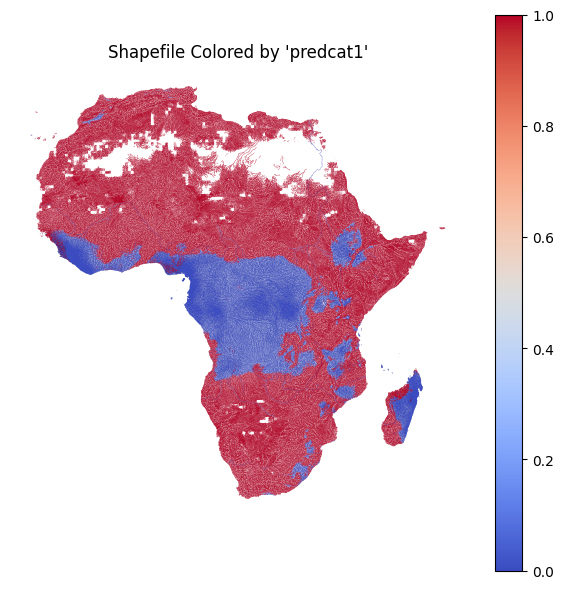

In [99]:
# 2. Read shapefile
gdf = gpd.read_file(shp_path)

# Attribute to color by
attr = "predcat1"   # e.g. "class", "type", "elevation"

# Plot
fig, ax = plt.subplots(figsize=(6, 6))

gdf.plot(
    column=attr,        # the attribute
    cmap="coolwarm",     # or "tab20", "Set3", "plasma", etc.
    legend=True,        # show colorbar/legend
    linewidth=0.2,
    #edgecolor="black",
    ax=ax
)
#ax.set_xlim([50, 180])
#ax.set_ylim([30, 80])
ax.set_title(f"Shapefile Colored by '{attr}'")
ax.axis('off')
#plt.show()
plt.tight_layout()
path_out = "/home/c1755103/AF/fig/af_gires.png"
plt.savefig(path_out, dpi=300)

In [36]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [83]:
type(geoms[0][1])

int

In [75]:
ref_transform

Affine(0.0083333333333333, 0.0, -19.0,
       0.0, -0.0083333333333333, 37.999999999999716)

In [76]:
ref_crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [ ]:
import matplotlib.pyplot as plt

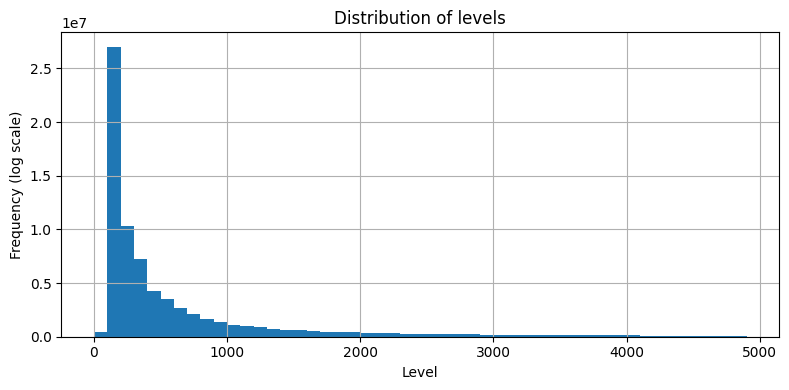

In [43]:
fname_length = "/home/c1755103/AF/dataset/raw/hyd_af_lup_15s.tif"
# plot the distribution of values of the flow accumulation raster

with rasterio.open(fname_length) as src:
    acc_data = src.read(1)
    acc_data = acc_data[acc_data > 0]  # filter out non-positive values
    acc_data = acc_data/4.0#1000.#.flatten()  # flatten to 1D array
    plt.figure(figsize=(8, 4))
    # specifiy bins and log scale for y-axis
    #bins = np.logspace(np.log10(acc_data.min()), np.log10(acc_data.max()), 50)
    bins = np.arange(1, 5000, 100)  # linear bins from 0 to 1 million with step of 1000
    plt.hist(acc_data, bins=bins)#, log=True)
    plt.title("Distribution of levels")
    plt.xlabel("Level")
    plt.ylabel("Frequency (log scale)")
    plt.grid()
    plt.tight_layout()
    plt.savefig("/home/c1755103/AF/fig/af_acc_30s_histogram.png", dpi=300)
    plt.show()

In [11]:
acc_data.max()

4294967295

### Preprocess soil parameters

Soil parameters can be obtained from different sources, including global soil databases and remote sensing products. Here we have used the high resolution product, at 1 km resolution, from the global dataset:

In [1]:
fname_dai = [
    "/share/home/c1755103/dataset/Dai_et_al_soil_global/theta_s_6L.tar.gz",
    "/share/home/c1755103/dataset/Dai_et_al_soil_global/log_k_s_6L.tar.gz",
    "/share/home/c1755103/dataset/Dai_et_al_soil_global/psi_s_6L.tar.gz",
    "/share/home/c1755103/dataset/Dai_et_al_soil_global/lambda_6L.tar.gz"
]


In [28]:
fname_bln = "/tmp/theta_s_l1"

def read_bnu_soil_binary(fname_bln, ncols=43200, nrows=21600):

    # BNU soil datasets often use these dimensions for 30" resolution
    # Check your specific readme for ncols/nrows (e.g., 43200 x 21600)
    ncols, nrows = 43200, 21600 
    # Read the raw binary data (usually 4-byte float32)
    data = np.fromfile(fname_bln, dtype=np.float64)#.reshape(-1)

    # Define coordinates (Global WGS84)
    lats = np.linspace(90, -90, nrows)
    lons = np.linspace(-180, 180, ncols)
    #print("Data shape before reshaping:", data.shape)
    # Reshape into a 2D spatial grid
    # Note: You may need to flip the array vertically depending on the origin
    grid = data.reshape((nrows, ncols))
    # To use with xarray after loading manually:
    da = xr.DataArray(grid, dims=['lat', 'lon'], coords={'lat': lats, 'lon': lons}, name='par')
    return da

In [58]:
# unzip the tar.gz files and read the files inside, then save as GeoTIFF after clipping to Africa bounds
import tarfile
import os
import xarray as xr
import rioxarray
import pyproj

# Force a single PROJ database to avoid mixed PROJ installations
proj_data_dir = pyproj.datadir.get_data_dir()
os.environ['PROJ_LIB'] = proj_data_dir
os.environ['PROJ_DATA'] = proj_data_dir
print(f"Using PROJ data from: {proj_data_dir}")

for path in fname_dai:
    print(f"Processing: {path}")
    with tarfile.open(path, "r:gz") as tar:
        # stream members to avoid loading entire archive into memory
        for member in tar:
            if ("l1" in member.name) and member.isfile():
                print(f"Using member: {member.name}")
                tar.extract(member, path="/tmp")
                bnu_path = os.path.join("/tmp", member.name)

                # open binary file and read as xarray DataArray
                da = read_bnu_soil_binary(bnu_path)

                # Rename spatial dimensions if needed
                rename_map = {}
                if 'lon' in da.dims:
                    rename_map['lon'] = 'x'
                elif 'longitude' in da.dims:
                    rename_map['longitude'] = 'x'
                if 'lat' in da.dims:
                    rename_map['lat'] = 'y'
                elif 'latitude' in da.dims:
                    rename_map['latitude'] = 'y'
                if rename_map:
                    da = da.rename(rename_map)

                # Write spatial metadata
                da = da.rio.set_spatial_dims(x_dim='x', y_dim='y', inplace=False)
                da = da.rio.write_crs('EPSG:4326', inplace=False)

                # Clip to Africa bounds using reference raster
                ref_da = rioxarray.open_rasterio(ref_path)
                if not ref_da.rio.crs:
                    ref_da = ref_da.rio.write_crs('EPSG:4326', inplace=False)

                da_clipped = da.rio.clip_box(
                    minx=bounds[0], miny=bounds[1], maxx=bounds[2], maxy=bounds[3]
                )

                # Reproject to match reference raster grid
                da_matched = da_clipped.rio.reproject_match(ref_da)

                # Save as GeoTIFF; member names like "theta_s_l1" have no extension
                out_name = os.path.basename(member.name)
                if not out_name.lower().endswith('.tif'):
                    out_name = out_name + '.tif'
                out_path = os.path.join('/home/c1755103/AF/dataset/postpp/', 'af_' + out_name)
                da_matched.rio.to_raster(out_path, driver='GTiff')

                print(f"Processed and saved: {out_path}")
                #break

Using PROJ data from: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj
Processing: /share/home/c1755103/dataset/Dai_et_al_soil_global/theta_s_6L.tar.gz
Using member: theta_s_l1


ERROR 1: PROJ: internal_proj_create_from_database: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Processed and saved: /home/c1755103/AF/dataset/postpp/af_theta_s_l1.tif
Processing: /share/home/c1755103/dataset/Dai_et_al_soil_global/log_k_s_6L.tar.gz
Using member: log_k_s_l1


ERROR 1: PROJ: internal_proj_create_from_database: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Processed and saved: /home/c1755103/AF/dataset/postpp/af_log_k_s_l1.tif
Processing: /share/home/c1755103/dataset/Dai_et_al_soil_global/psi_s_6L.tar.gz
Using member: psi_s_l1


ERROR 1: PROJ: internal_proj_create_from_database: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Processed and saved: /home/c1755103/AF/dataset/postpp/af_psi_s_l1.tif
Processing: /share/home/c1755103/dataset/Dai_et_al_soil_global/lambda_6L.tar.gz
Using member: lambda_l1


ERROR 1: PROJ: internal_proj_create_from_database: /home/c1755103/anaconda3/envs/cwld/lib/python3.11/site-packages/pyproj/proj_dir/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Processed and saved: /home/c1755103/AF/dataset/postpp/af_lambda_l1.tif


In [56]:
da_matched.rio.to_raster(out_path, driver='GTiff')